# Подбор гиперпараметров

В этом ноутбуке разберём **подбор гиперпараметров** моделей: как правильно оценивать качество, избегать переобучения и автоматически искать хорошие настройки с помощью перекрёстной проверки.

**Цели ноутбука:**
- Понять разбиение на train/val/test и роль валидационной выборки.
- Разобрать **K-fold cross-validation** и зачем она нужна.
- Научиться использовать `GridSearchCV` и `RandomizedSearchCV` из `sklearn`.
- Увидеть на примере, как переобучение проявляется при неправильном выборе гиперпараметров.

---

**Содержание:** Train/val/test и переобучение → K-fold CV → GridSearchCV → RandomizedSearchCV → Выводы.


## Train / validation / test и переобучение

**Обучающая выборка (train)** используется для подстройки весов модели. Если по ней же выбирать гиперпараметры (например, глубину дерева или число соседей k), мы косвенно "подгоняемся" под train, и оценка качества становится излишне оптимистичной — модель может **переобучиться**.

Поэтому:
- **Валидационная выборка (validation)** — отдельная часть данных, на которой мы **выбираем гиперпараметры** и решения (какую модель взять). Не обучаем на ней модель.
- **Тестовая выборка (test)** — ещё одна часть, которую мы используем **только в самом конце** для итоговой оценки качества. К тесту не должны "подглядывать" ни при обучении, ни при выборе гиперпараметров.

Типичная схема: разбить данные на train+val и test (например, 80% / 20%). На train обучаем модели с разными гиперпараметрами, на val смотрим метрику и выбираем лучшую конфигурацию. Финальную оценку сообщаем по test.

**Перекрёстная проверка (CV)** позволяет эффективнее использовать данные: вместо одного разбиения на train/val мы несколько раз по очереди делаем разные разбиения и усредняем метрику, чтобы выбор гиперпараметров был устойчивее.


## K-fold cross-validation

При **K-fold CV** выборка делится на $K$ частей (фолдов). $K$ раз повторяем: одна часть выступает как валидация, остальные $K-1$ — как обучение. Метрику считаем на валидационной части каждый раз; итоговая оценка — среднее (и можно смотреть разброс) по $K$ прогонам.

Таким образом, каждый объект ровно один раз побывает в роли валидационного. Это даёт более надёжную оценку обобщающей способности, чем одно разбиение train/val. В sklearn для этого используется `cross_val_score` или встроенная CV внутри `GridSearchCV`.

Пример: оценка точности kNN с разным $k$ по 5-fold CV.


In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

X, y = load_iris(return_X_y=True)
pipe = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier())])

k_values = [1, 3, 5, 7, 11, 15, 21]
scores = []
for k in k_values:
    pipe.set_params(knn__n_neighbors=k)
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    scores.append(cv_scores.mean())
    print(f"k={k:2d}  accuracy (5-fold CV) = {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

best_k = k_values[np.argmax(scores)]
print(f"\nПо 5-fold CV лучший k = {best_k}")

k= 1  accuracy (5-fold CV) = 0.947 (+/- 0.068)
k= 3  accuracy (5-fold CV) = 0.953 (+/- 0.068)
k= 5  accuracy (5-fold CV) = 0.960 (+/- 0.050)
k= 7  accuracy (5-fold CV) = 0.960 (+/- 0.065)
k=11  accuracy (5-fold CV) = 0.947 (+/- 0.068)
k=15  accuracy (5-fold CV) = 0.940 (+/- 0.078)
k=21  accuracy (5-fold CV) = 0.947 (+/- 0.080)

По 5-fold CV лучший k = 5


## GridSearchCV

**GridSearchCV** перебирает все комбинации гиперпараметров из заданной сетки. Для каждой комбинации по умолчанию выполняется K-fold CV (метрика усредняется по фолдам), и выбирается комбинация с лучшим средним результатом. После поиска можно обучить финальную модель на всех данных (refit=True по умолчанию) лучшими параметрами.

Важно: внутри GridSearchCV разбиение на фолды делается так, что **на каждом шаге модель обучается только на train-части фолда**, а оценивается на val-части, поэтому тестовая выборка не участвует в выборе гиперпараметров. Итоговую оценку качества лучше проверить на отдельном test set или через вложенную CV.

Пример: поиск по сетке для kNN (k и веса).


In [2]:
from sklearn.model_selection import GridSearchCV, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 11, 15],
    "knn__weights": ["uniform", "distance"],
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", verbose=0)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая оценка (CV):", f"{grid.best_score_:.3f}")
print("Точность на отложенном тесте:", f"{grid.score(X_test, y_test):.3f}")

Лучшие параметры: {'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Лучшая оценка (CV): 0.958
Точность на отложенном тесте: 1.000


## RandomizedSearchCV

Когда сетка гиперпараметров очень большая, полный перебор (GridSearchCV) становится дорогим. **RandomizedSearchCV** случайным образом выбирает заданное число комбинаций из распределений параметров (или из списков). Часто за меньшее время удаётся найти хорошую конфигурацию.

Для непрерывных параметров (например, C для SVM) задают распределение (например, `scipy.stats.loguniform`). Для дискретных — список значений. Параметр `n_iter` задаёт, сколько комбинаций попробовать.

Пример: случайный поиск по числу соседей и метрике.


In [3]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 25, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # L1 и L2 (манхэттенское и евклидово)
}
rnd = RandomizedSearchCV(pipe, param_dist, n_iter=20, cv=5, scoring="accuracy", random_state=42)
rnd.fit(X_train, y_train)

print("Лучшие параметры (random search):", rnd.best_params_)
print("Лучшая оценка (CV):", f"{rnd.best_score_:.3f}")
print("Точность на тесте:", f"{rnd.score(X_test, y_test):.3f}")

Лучшие параметры (random search): {'knn__weights': 'distance', 'knn__p': 2, 'knn__n_neighbors': 9}
Лучшая оценка (CV): 0.958
Точность на тесте: 1.000


## Переобучение на примере дерева решений

Наглядно переобучение видно, когда модель слишком сложная: на train метрика отличная, на val/test — хуже. Ниже сравниваем деревья разной глубины по train и по CV.


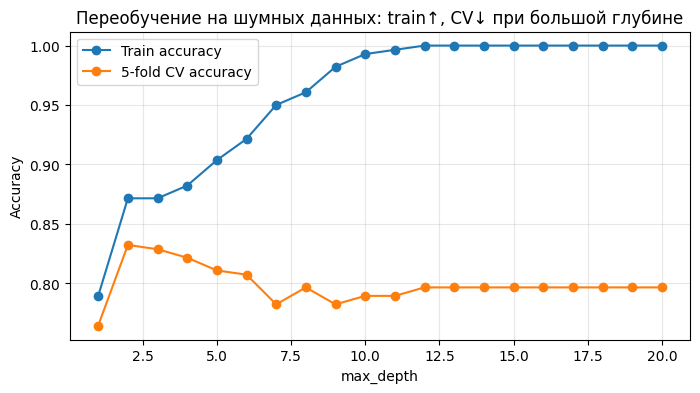

In [4]:
# Более наглядный пример переобучения на шумных данных
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Шумные данные make_moons: дерево может идеально выучить train, но хуже обобщать
X, y = make_moons(n_samples=400, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

depths = list(range(1, 21))
train_acc = []
cv_acc = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    cv_scores = cross_val_score(tree, X_train, y_train, cv=5)
    cv_acc.append(cv_scores.mean())

plt.figure(figsize=(8, 4))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, cv_acc, marker="o", label="5-fold CV accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Переобучение на шумных данных: train↑, CV↓ при большой глубине")
plt.grid(True, alpha=0.3)
plt.show()

## Выводы

- Для честной оценки модели и выбора гиперпараметров нужны отдельные выборки: обучение, валидация (или CV) и тест; тест не должен участвовать в выборе гиперпараметров.
- K-fold CV даёт устойчивую оценку обобщающей способности и позволяет эффективнее использовать данные при подборе настроек.
- GridSearchCV перебирает все комбинации по сетке, RandomizedSearchCV — случайную выборку комбинаций; оба используют CV внутри и возвращают лучшие параметры и обученную модель (refit=True).
- Переобучение проявляется как высокое качество на train и более низкое на val/test; подбор гиперпараметров по CV помогает выбрать разумную сложность модели.
